# Decode Lab - Project 4

##Sentiment Analysis using Natural Language Processing



**STEP 1 - Importing Required Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from nltk.corpus import stopwords, wordnet
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from scipy.sparse import csr_matrix

**STEP 2 - Loading the Dataset**

In [ ]:
df = pd.read_csv(
    "IMDB_Dataset.csv",
    engine="python",
    on_bad_lines="skip"
)

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**STEP 3 - Understanding the Dataset**

3.1 Dataset Shape

In [ ]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 46679
Number of Columns: 2


3.2 Column Names

In [ ]:
df.columns

Index(['review', 'sentiment'], dtype='object')

3.3 Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46679 entries, 0 to 46678
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     46679 non-null  object
 1   sentiment  46679 non-null  object
dtypes: object(2)
memory usage: 729.5+ KB


3.4 Statistical Summary

In [ ]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (46679, 2)

Data Types:
review       object
sentiment    object
dtype: object

Missing Values:
review       0
sentiment    0
dtype: int64


3.5 Sentiment Distribution

Sentiment Distribution:
sentiment
positive    23363
negative    23316
Name: count, dtype: int64


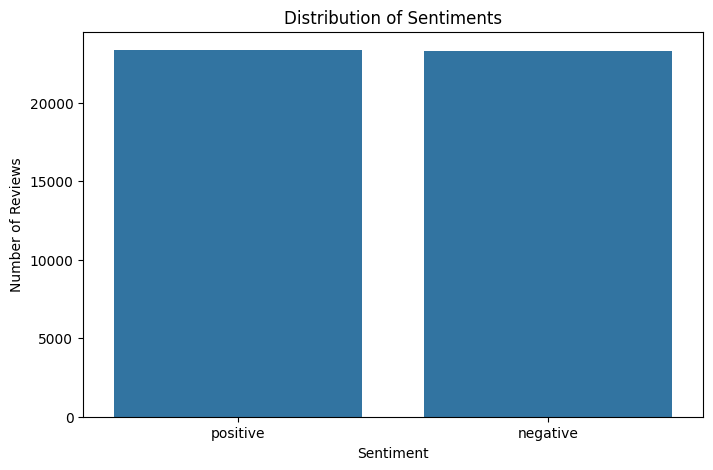

In [ ]:
print("Sentiment Distribution:")
print(df["sentiment"].value_counts())
plt.figure(figsize=(8, 5))

sns.countplot(x="sentiment", data=df)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Sentiments")

plt.show()

3.6 Random Sample

In [ ]:
df.sample(5, random_state=42)

,review,sentiment
1219,"The long list of ""big"" names in this flick (in...",negative
10016,"A really very bad movie, with a very few good ...",negative
19499,My wife and I thought that with this cast and ...,negative
42564,"""The Snow Queen"" is based on the famous and ve...",negative
43117,Perhaps I'm one of the only avid horror fans w...,positive


**STEP 4 - Text Data Preprocessing**

4.1 Convert Sentiment Labels to Numeric

In [ ]:
df["sentiment"] = df["sentiment"].map({
    "positive": 1,
    "negative": 0
})

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


4.2 Import Text Cleaning Libraries

In [ ]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

4.3 Create a Text Cleaning Function

In [ ]:
stemmer = PorterStemmer()

def clean_text(text):

    text = text.lower()

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"http\S+|www\S+", "", text)

    text = re.sub(r"[^a-zA-Z]", " ", text)

    words = text.split()

    words = [
        stemmer.stem(word)
        for word in words
        if word not in stopwords.words("english")
    ]

    return " ".join(words)

4.4 Apply Text Cleaning

In [ ]:
df["clean_review"] = df["review"].apply(clean_text)

df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one review mention watch oz episod hook right ...
1,A wonderful little production. <br /><br />The...,wonder littl product film techniqu unassum old...
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,basic famili littl boy jake think zombi closet...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visual stun film...


4.5 Check Original vs Cleaned Reviews

In [ ]:
df[
    ["review", "clean_review"]
].sample(5, random_state=42)

,review,clean_review
1219,"The long list of ""big"" names in this flick (in...",long list big name flick includ ubiquit john m...
10016,"A really very bad movie, with a very few good ...",realli bad movi good moment qualiti start preg...
19499,My wife and I thought that with this cast and ...,wife thought cast director movi would least wo...
42564,"""The Snow Queen"" is based on the famous and ve...",snow queen base famou beauti fairytal han chri...
43117,Perhaps I'm one of the only avid horror fans w...,perhap one avid horror fan think recent overlo...


4.6 Review Length Analysis

In [ ]:
df["review_length"] = df["clean_review"].apply(len)

df["review_length"].describe()

,review_length
count,46679.000000
mean,721.443026
std,557.927547
min,17.000000
25%,377.000000
50%,531.000000
75%,876.000000
max,8286.000000


4.7 Distribution of Review Lengths

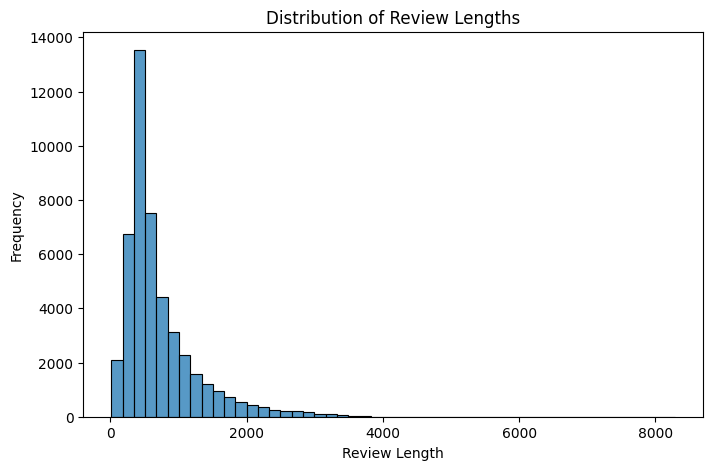

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["review_length"],
    bins=50
)

plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length")
plt.ylabel("Frequency")

plt.show()

**STEP 5 - Feature Extraction using TF-IDF**

5.1 Convert Text into Numerical Features

In [48]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df["clean_review"])

X.shape

(46679, 5000)

5.2 Feature Matrix Information

In [49]:
print("Feature Matrix Shape:", X.shape)

print("\nNumber of Features:")
print(len(tfidf.get_feature_names_out()))

Feature Matrix Shape: (46679, 5000)

Number of Features:
5000


5.3 Display Sample Features

In [50]:
feature_names = tfidf.get_feature_names_out()

print(feature_names[:50])

['aaron' 'abandon' 'abc' 'abduct' 'abil' 'abl' 'aboard' 'abomin' 'abort'
 'abound' 'abraham' 'abrupt' 'abruptli' 'absenc' 'absent' 'absolut'
 'absorb' 'abstract' 'absurd' 'abund' 'abus' 'abysm' 'academi' 'accent'
 'accept' 'access' 'accid' 'accident' 'acclaim' 'accompani' 'accomplish'
 'accord' 'account' 'accur' 'accuraci' 'accus' 'ace' 'achiev' 'acid'
 'acknowledg' 'acquaint' 'acquir' 'across' 'act' 'action' 'activ' 'actor'
 'actress' 'actual' 'ad']


5.4 Convert Sentiment Column into Target Variable

In [51]:
y = df["sentiment"]

print(y.value_counts())

sentiment
1    23363
0    23316
Name: count, dtype: int64


5.5 Train-Test Split

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (37343, 5000)
Testing Data: (9336, 5000)


**STEP 6 - Building and Training the Sentiment Classification Model**

6.1 Initialize the Naive Bayes Model

In [53]:
model = MultinomialNB()

6.2 Train the Model

In [54]:
model.fit(X_train, y_train)

print("Model Training Completed Successfully")

Model Training Completed Successfully


6.3 Make Predictions on Test Data

In [55]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 0 0 0 1 1 0 1 1 1 0 0 0 1 0 1 0 0 0 1]


6.4 Calculate Model Accuracy

In [56]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy*100,2), "%")

Model Accuracy: 85.13 %


6.5 Classification Report

In [57]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      4589
           1       0.85      0.86      0.85      4747

    accuracy                           0.85      9336
   macro avg       0.85      0.85      0.85      9336
weighted avg       0.85      0.85      0.85      9336



6.6 Confusion Matrix

In [58]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[3856  733]
 [ 655 4092]]


6.7 Visualize Confusion Matrix

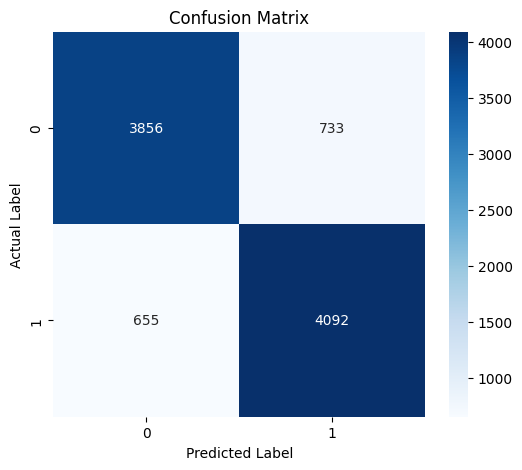

In [59]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.show()

6.8 Display Model Performance Summary

In [60]:
print("Accuracy Score :", accuracy_score(y_test, y_pred))
print("Precision, Recall and F1-Score shown above.")

Accuracy Score : 0.8513281919451585
Precision, Recall and F1-Score shown above.


**STEP 7 - Testing the Model on Custom Reviews**

7.1 Create a Prediction Function

In [61]:
def predict_sentiment(review):

    cleaned_review = clean_text(review)

    review_vector = tfidf.transform([cleaned_review])

    prediction = model.predict(review_vector)[0]

    if prediction == 1:
        return "Positive Review "
    else:
        return "Negative Review "

7.2 Test with a Positive Review

In [62]:
review1 = """
This movie was absolutely amazing.
The acting was fantastic and the storyline was engaging.
I would highly recommend it.
"""

print(predict_sentiment(review1))

Positive Review 


7.3 Test with a Negative Review

In [63]:
review2 = """
This movie was boring and a complete waste of time.
The acting was terrible and the story made no sense.
"""

print(predict_sentiment(review2))

Negative Review 


7.4 Test Multiple Reviews Together

In [64]:
sample_reviews = [

    "This movie is fantastic and worth watching",

    "One of the worst films I have ever seen",

    "The plot was interesting and the acting was great",

    "Terrible movie with poor direction",

    "Absolutely loved this film"
]

for review in sample_reviews:

    print("Review:", review)

    print("Prediction:", predict_sentiment(review))

    print("-" * 60)

Review: This movie is fantastic and worth watching
Prediction: Positive Review 
------------------------------------------------------------
Review: One of the worst films I have ever seen
Prediction: Negative Review 
------------------------------------------------------------
Review: The plot was interesting and the acting was great
Prediction: Negative Review 
------------------------------------------------------------
Review: Terrible movie with poor direction
Prediction: Negative Review 
------------------------------------------------------------
Review: Absolutely loved this film
Prediction: Positive Review 
------------------------------------------------------------


**STEP 8 - Conclusion**

A Sentiment Analysis model was successfully developed using the IMDB Movie Reviews Dataset.

The project involved:

• Data Understanding
• Text Preprocessing
• Feature Extraction using TF-IDF
• Train-Test Split
• Model Building using Multinomial Naive Bayes
• Performance Evaluation
• Custom Review Prediction

The model achieved an accuracy of 85.13% on unseen test data and was able to correctly classify movie reviews as Positive or Negative.

This project demonstrates the application of Natural Language Processing (NLP) and Machine Learning techniques for text classification tasks.